# How to add memory to chatbots

A key feature of chatbots is their ability to use the content of previous conversational turns as context. This state management can take several forms, including:

- Simply stuffing previous messages into a chat model prompt.
- The above, but trimming old messages to reduce the amount of distracting information the model has to deal with.
- More complex modifications like synthesizing summaries for long running conversations.

We'll go into more detail on a few techniques below!

:::note

This how-to guide previously built a chatbot using [RunnableWithMessageHistory](https://python.langchain.com/api_reference/core/runnables/langchain_core.runnables.history.RunnableWithMessageHistory.html). You can access this version of the guide in the [v0.2 docs](https://python.langchain.com/v0.2/docs/how_to/chatbots_memory/).

As of the v0.3 release of LangChain, we recommend that LangChain users take advantage of [LangGraph persistence](https://langchain-ai.github.io/langgraph/concepts/persistence/) to incorporate `memory` into new LangChain applications.

If your code is already relying on `RunnableWithMessageHistory` or `BaseChatMessageHistory`, you do **not** need to make any changes. We do not plan on deprecating this functionality in the near future as it works for simple chat applications and any code that uses `RunnableWithMessageHistory` will continue to work as expected.

Please see [How to migrate to LangGraph Memory](/docs/versions/migrating_memory/) for more details.
:::

## Setup

You'll need to install a few packages, and have your OpenAI API key set as an environment variable named `OPENAI_API_KEY`:

Let's also set up a chat model that we'll use for the below examples.

In [ ]:
from pydantic import SecretStr
from langchain_perplexity import ChatPerplexity
from workflow_engine.config import settings

if settings.LANGSMITH_TRACING:
    # Initialize LangSmith tracing or logger
    from langsmith import Client
    client = Client(api_url=settings.LANGSMITH_ENDPOINT, api_key=settings.LANGSMITH_API_KEY, )

    # Ensure the project exists
    if client.has_project(project_name=settings.LANGSMITH_PROJECT) is False:
        client.create_project(project_name=settings.LANGSMITH_PROJECT)
    
    client.read_project(project_name=settings.LANGSMITH_PROJECT)

model = ChatPerplexity(
    temperature=0.7,
    model="sonar",
    timeout=60,
    api_key=SecretStr(settings.PPLX_API_KEY),
)

## Message passing

The simplest form of memory is simply passing chat history messages into a chain. Here's an example:

In [8]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate(
    [
        SystemMessage(
            content="You are a helpful assistant. Answer all questions to the best of your ability."
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

chain = prompt | model

ai_msg = chain.invoke(
    {
        "messages": [
            HumanMessage(
                content="Translate from English to French: I love programming."
            ),
            AIMessage(content="J'adore la programmation."),
            HumanMessage(content="What did you just say?"),
        ],
    }
)
print(ai_msg.content)

I said **"J'adore la programmation."**, which means **"I love programming."** in French[1][2].


We can see that by passing the previous conversation into a chain, it can use it as context to answer questions. This is the basic concept underpinning chatbot memory - the rest of the guide will demonstrate convenient techniques for passing or reformatting messages.

## Automatic history management

The previous examples pass messages to the chain (and model) explicitly. This is a completely acceptable approach, but it does require external management of new messages. LangChain also provides a way to build applications that have memory using LangGraph's [persistence](https://langchain-ai.github.io/langgraph/concepts/persistence/). You can [enable persistence](https://langchain-ai.github.io/langgraph/how-tos/persistence/) in LangGraph applications by providing a `checkpointer` when compiling the graph.

In [9]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

workflow = StateGraph(state_schema=MessagesState)


# Define the function that calls the model
def call_model(state: MessagesState):
    system_prompt = (
        "You are a helpful assistant. Answer all questions to the best of your ability."
    )
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model.invoke(messages)
    return {"messages": response}


# Define the node and edge
workflow.add_node("model", call_model)
workflow.add_edge(START, "model")

# Add simple in-memory checkpointer
# highlight-start
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
# highlight-end

 We'll pass the latest input to the conversation here and let LangGraph keep track of the conversation history using the checkpointer:

In [10]:
app.invoke(
    {"messages": [HumanMessage(content="Translate to French: I love programming.")]},
    config={"configurable": {"thread_id": "1"}},
)

{'messages': [HumanMessage(content='Translate to French: I love programming.', additional_kwargs={}, response_metadata={}, id='89c88434-a591-4eaa-b11d-961552c08991'),
  AIMessage(content='The French translation of "I love programming." is **"J\'adore la programmation."**[1][5]. \n\nThis is the most consistent and accurate translation from multiple sources, including LangChain and OpenAI\'s ChatGPT examples. Note that "programmation" is the common French term for "programming" in the context of computer programming.', additional_kwargs={'citations': ['https://langchain-cn.readthedocs.io/en/latest/modules/models/chat/getting_started.html', 'https://www.youtube.com/watch?v=Wzvdej5h2lQ', 'https://python.langchain.com/docs/integrations/chat/ollama/', 'https://linnk.ai/tools/code-translator/', 'https://minimaxir.com/2023/07/langchain-problem/', 'https://www.codecademy.com/article/translate-code-into-different-languages-with-chat-gpt', 'https://docs.sambanova.ai/cloud/docs/integrations/langch

In [11]:
app.invoke(
    {"messages": [HumanMessage(content="What did I just ask you?")]},
    config={"configurable": {"thread_id": "1"}},
)

{'messages': [HumanMessage(content='Translate to French: I love programming.', additional_kwargs={}, response_metadata={}, id='89c88434-a591-4eaa-b11d-961552c08991'),
  AIMessage(content='The French translation of "I love programming." is **"J\'adore la programmation."**[1][5]. \n\nThis is the most consistent and accurate translation from multiple sources, including LangChain and OpenAI\'s ChatGPT examples. Note that "programmation" is the common French term for "programming" in the context of computer programming.', additional_kwargs={'citations': ['https://langchain-cn.readthedocs.io/en/latest/modules/models/chat/getting_started.html', 'https://www.youtube.com/watch?v=Wzvdej5h2lQ', 'https://python.langchain.com/docs/integrations/chat/ollama/', 'https://linnk.ai/tools/code-translator/', 'https://minimaxir.com/2023/07/langchain-problem/', 'https://www.codecademy.com/article/translate-code-into-different-languages-with-chat-gpt', 'https://docs.sambanova.ai/cloud/docs/integrations/langch

## Modifying chat history

Modifying stored chat messages can help your chatbot handle a variety of situations. Here are some examples:

### Trimming messages

LLMs and chat models have limited context windows, and even if you're not directly hitting limits, you may want to limit the amount of distraction the model has to deal with. One solution is trim the history messages before passing them to the model. Let's use an example history with the `app` we declared above:

In [12]:
demo_ephemeral_chat_history = [
    HumanMessage(content="Hey there! I'm Nemo."),
    AIMessage(content="Hello!"),
    HumanMessage(content="How are you today?"),
    AIMessage(content="Fine thanks!"),
]

app.invoke(
    {
        "messages": demo_ephemeral_chat_history
        + [HumanMessage(content="What's my name?")]
    },
    config={"configurable": {"thread_id": "2"}},
)

{'messages': [HumanMessage(content="Hey there! I'm Nemo.", additional_kwargs={}, response_metadata={}, id='c2df2e9f-57d5-437e-9e5f-c8a41c9fe16e'),
  AIMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='739704ac-940b-4aed-a30f-8cbbe01bd414'),
  HumanMessage(content='How are you today?', additional_kwargs={}, response_metadata={}, id='605d6621-9ad8-44af-a94d-c9aa8f9e47af'),
  AIMessage(content='Fine thanks!', additional_kwargs={}, response_metadata={}, id='5aa110dd-f2a4-4bbf-a31e-25d5a50f05a8'),
  HumanMessage(content="What's my name?", additional_kwargs={}, response_metadata={}, id='6ea5dc16-b582-4f20-b17c-f3b06a0bac39'),
  AIMessage(content='Your name is **Nemo**, as you introduced yourself[1]. The name Nemo is of Latin origin, meaning "nobody" or "no one"[1][3][4]. It has literary significance, notably as the name of Captain Nemo in Jules Verne\'s *Twenty Thousand Leagues Under the Sea* and the character in the animated film *Finding Nemo*[1][3]. Additionally, N

We can see the app remembers the preloaded name.

But let's say we have a very small context window, and we want to trim the number of messages passed to the model to only the 2 most recent ones. We can use the built in [trim_messages](/docs/how_to/trim_messages/) util to trim messages based on their token count before they reach our prompt. In this case we'll count each message as 1 "token" and keep only the last two messages:

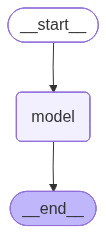

In [13]:
from langchain_core.messages import trim_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

# Define trimmer
# highlight-start
# count each message as 1 "token" (token_counter=len) and keep only the last three messages
trimmer = trim_messages(strategy="last", max_tokens=3, token_counter=len)
# highlight-end

workflow = StateGraph(state_schema=MessagesState)


# Define the function that calls the model
def call_model(state: MessagesState):
    # highlight-start
    trimmed_messages = trimmer.invoke(state["messages"])
    system_prompt = (
        "You are a helpful assistant. Answer all questions to the best of your ability."
    )
    messages = [SystemMessage(content=system_prompt)] + trimmed_messages
    # highlight-end
    response = model.invoke(messages)
    return {"messages": response}


# Define the node and edge
workflow.add_node("model", call_model)
workflow.add_edge(START, "model")

# Add simple in-memory checkpointer
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
app

Let's call this new app and check the response

In [14]:
app.invoke(
    {
        "messages": demo_ephemeral_chat_history
        + [HumanMessage(content="What is my name?")]
    },
    config={"configurable": {"thread_id": "3"}},
)

{'messages': [HumanMessage(content="Hey there! I'm Nemo.", additional_kwargs={}, response_metadata={}, id='c2df2e9f-57d5-437e-9e5f-c8a41c9fe16e'),
  AIMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='739704ac-940b-4aed-a30f-8cbbe01bd414'),
  HumanMessage(content='How are you today?', additional_kwargs={}, response_metadata={}, id='605d6621-9ad8-44af-a94d-c9aa8f9e47af'),
  AIMessage(content='Fine thanks!', additional_kwargs={}, response_metadata={}, id='5aa110dd-f2a4-4bbf-a31e-25d5a50f05a8'),
  HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='f1b6402a-73bd-4c12-8ec4-0d3aa525feda'),
  AIMessage(content='I do not know your name as it has not been provided in our conversation or search results. There is no information available that identifies your name. If you share your name, I can use it in our conversation.', additional_kwargs={'citations': ['https://www.youtube.com/watch?v=OM5dhjUUtdM', 'https://autogpt.net/chatgpt-is-ad

We can see that `trim_messages` was called and only the two most recent messages will be passed to the model. In this case, this means that the model forgot the name we gave it.

Check out our [how to guide on trimming messages](/docs/how_to/trim_messages/) for more.

### Summary memory

We can use this same pattern in other ways too. For example, we could use an additional LLM call to generate a summary of the conversation before calling our app. Let's recreate our chat history:

In [40]:
demo_ephemeral_chat_history = [
    HumanMessage(content="Hey there! I'm Nemo."),
    AIMessage(content="Hello!"),
    HumanMessage(content="How are you today?"),
    AIMessage(content="Fine thanks!"),
]

And now, let's update the model-calling function to distill previous interactions into a summary:

In [47]:
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

workflow = StateGraph(state_schema=MessagesState)


# Define the function that calls the model
def call_model(state: MessagesState):
    system_prompt = (
        "You are a helpful assistant. "
        "Answer all questions to the best of your ability. "
        "The provided chat history includes a summary of the earlier conversation."
    )
    system_message = SystemMessage(content=system_prompt)
    message_history = state["messages"][:-1]  # exclude the most recent user input
    # Summarize the messages if the chat history reaches a certain size
    if len(message_history) >= 4:
        first_human_message = state["messages"][0]
        last_human_message = state["messages"][-1]
        print("first_human_message", first_human_message)
        print("last_human_message", last_human_message)
        print("message_history", message_history)
        print("state['messages']", state["messages"])
        # Invoke the model to generate conversation summary
        summary_prompt = (
            "Distill the above chat messages into a single summary message. "
            "Include as many specific details as you can."
        )
        print("summarizing...", message_history[1:] + [HumanMessage(content=summary_prompt)])
        summary_message = model.invoke(
            message_history + [HumanMessage(content=summary_prompt)]
        )

        # Delete messages that we no longer want to show up
        delete_messages = [RemoveMessage(id=m.id) for m in state["messages"]]
        # Re-add user message
        human_message = HumanMessage(content=last_human_message.content)
        # Call the model with summary & response
        response = model.invoke([system_message, first_human_message, summary_message, human_message])
        message_updates = [first_human_message, summary_message, human_message, response] + delete_messages
    else:
        message_updates = model.invoke([system_message] + state["messages"])

    return {"messages": message_updates}


# Define the node and edge
workflow.add_node("model", call_model)
workflow.add_edge(START, "model")

# Add simple in-memory checkpointer
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

Let's see if it remembers the name we gave it:

In [48]:
app.invoke(
    {
        "messages": demo_ephemeral_chat_history
        + [HumanMessage("What did I say my name was?")]
    },
    config={"configurable": {"thread_id": "4"}},
)

first_human_message content="Hey there! I'm Nemo." additional_kwargs={} response_metadata={} id='de7cc610-4608-4b8f-8881-9266476b83c2'
last_human_message content='What did I say my name was?' additional_kwargs={} response_metadata={} id='a3533ca9-0254-4070-a3aa-50e41c3ac4c8'
message_history [HumanMessage(content="Hey there! I'm Nemo.", additional_kwargs={}, response_metadata={}, id='de7cc610-4608-4b8f-8881-9266476b83c2'), AIMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='37962c11-ddb0-4060-8af2-6ace1e1653b8'), HumanMessage(content='How are you today?', additional_kwargs={}, response_metadata={}, id='cd15f5de-2ad0-4024-b16d-06477599fb87'), AIMessage(content='Fine thanks!', additional_kwargs={}, response_metadata={}, id='271e7d8e-93bc-4ca1-a979-40fb7d473355')]
state['messages'] [HumanMessage(content="Hey there! I'm Nemo.", additional_kwargs={}, response_metadata={}, id='de7cc610-4608-4b8f-8881-9266476b83c2'), AIMessage(content='Hello!', additional_kwargs={}, res

{'messages': [AIMessage(content='The chat conversation involves a brief, friendly exchange where the user Nemo introduces themselves, and the assistant responds with greetings and a polite inquiry about well-being. Nemo then asks how the assistant is doing, and the assistant replies that it is fine. The overall tone is simple and courteous, with minimal interaction beyond basic pleasantries.', additional_kwargs={'citations': ['https://vomo.ai/blog/how-can-i-summarize-an-entire-whatsapp-conversation', 'https://www.getmesa.com/blog/how-to-summarize-help-scout-conversations-with-ai/', 'https://www.notta.ai/en/blog/how-to-summarize-conversation', 'https://community.liveperson.com/kb/articles/2007-overview-of-automated-conversation-summaries', 'https://research.google/blog/conversation-summaries-in-google-chat/', 'https://community.openai.com/t/strategy-for-chat-history-context-window-and-summaries/155423', 'https://learn.microsoft.com/en-us/azure/ai-services/language-service/summarization/

Note that invoking the app again will keep accumulating the history until it reaches the specified number of messages (four in our case). At that point we will generate another summary generated from the initial summary plus new messages and so on.